# Dysarthria ASR Pipeline — TORGO Evaluation
**Model**: `distil-whisper/distil-large-v3` + **LLM Repair**: `llama-3.3-70b-versatile` (Groq)
**Dataset**: `abnerh/TORGO-database` | **Metrics**: WER, CER

---
> **Before running:** Runtime → Change runtime type → **T4 GPU** (free tier)


In [ ]:
# @title Step 1 — Check GPU
import subprocess
result = subprocess.run(
    ['nvidia-smi', '--query-gpu=name,memory.total,memory.free', '--format=csv,noheader'],
    capture_output=True, text=True
)
if result.returncode == 0:
    name, total, free = result.stdout.strip().split(', ')
    print(f"GPU : {name} | VRAM total: {total} | VRAM free: {free}")
else:
    print("No GPU found. Go to Runtime -> Change runtime type -> T4 GPU")
    print("CPU mode works but is ~10-20x slower.")


GPU : Tesla T4 | VRAM total: 15360 MiB | VRAM free: 14913 MiB


In [ ]:
# @title Step 2 — Install Dependencies (~2 min)
%%capture
!pip install -q transformers datasets accelerate soundfile jiwer langchain langchain-core langchain-groq tqdm
print("Packages installed.")


In [ ]:
# @title Step 3 — Groq API Key
# Get a free key at https://console.groq.com
import os
from getpass import getpass
GROQ_API_KEY = getpass("Paste your Groq API key: ")
os.environ["GROQ_API_KEY"] = GROQ_API_KEY
print("Key set.")



Paste your Groq API key: ··········
Key set.


In [ ]:
# @title Step 4 — Load distil-whisper/distil-large-v3
import gc, torch
from transformers import pipeline

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

device      = 0 if torch.cuda.is_available() else -1
torch_dtype = torch.float16 if torch.cuda.is_available() else torch.float32
print(f"{'GPU' if device == 0 else 'CPU'} mode | dtype = {torch_dtype}")
print("Loading model...")

asr_model = pipeline(
    "automatic-speech-recognition",
    model="distil-whisper/distil-large-v3",
    device=device,
    torch_dtype=torch_dtype,
    return_timestamps="word",
)
print("ASR model ready.")


GPU mode | dtype = torch.float16
Loading model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/539 [00:00<?, ?it/s]

Passing `generation_config` together with generation-related arguments=({'return_timestamps'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


ASR model ready.


### Dataset Notes — `abnerh/TORGO-database`
- **~5.5 hrs** dysarthric speech + **~8 hrs** healthy control speech
- Speaker codes: `FC01` = Female Control #1, `M04` = Male Dysarthric #4
- No official dev/test split — we sample from `train`
- Columns: `audio`, `text`, `gender`, `speech_status`, `duration`
- Transcripts normalized (punctuation removed, casing preserved)


In [ ]:
# @title Step 5 — Load and Inspect TORGO Dataset
# @markdown Set MAX_SAMPLES (60 = quick run, 0 = all ~13k samples)
MAX_SAMPLES            = 60    # @param {type:"integer"}
FILTER_DYSARTHRIC_ONLY = True  # @param {type:"boolean"}

from datasets import load_dataset, Audio
from collections import Counter
import pandas as pd
import re


print("Downloading abnerh/TORGO-database...")
ds = load_dataset("abnerh/TORGO-database", split="train", trust_remote_code=True)
ds = ds.cast_column("audio", Audio(sampling_rate=16000))

'''

yahaaaaaaaaaa

'''
# Keep only severe dysarthric speakers (lower intelligibility)
# TORGO speaker codes: M01-M05 dysarthric, F01-F03 dysarthric
# Severity roughly: MC01/FC01 = mild, M01/M02/F01 = severe
SEVERE_SPEAKERS = ["M01", "M02", "M04", "F03"]  # known severe in TORGO

# def is_severe(sample):
#     path = sample["audio"].get("path", "") or ""
#     import os, re
#     fname = os.path.basename(str(path))
#     match = re.match(r'([MF][CD]?\d+)', fname)
#     spk = match.group(1) if match else ""
#     return any(s in spk for s in SEVERE_SPEAKERS)
def is_severe(sample):
    # After cast_column, access path via the decoded dict
    audio = sample["audio"]
    # Try different ways to get the path
    if isinstance(audio, dict):
        path = audio.get("path", "") or ""
    else:
        path = getattr(audio, "path", "") or ""

    fname = os.path.basename(str(path))
    match = re.match(r'([MF][CD]?\d+)', fname)
    spk = match.group(1) if match else ""
    return any(s in spk for s in SEVERE_SPEAKERS)

ds_severe = ds.filter(is_severe)
if len(ds_severe) > 10:
    ds = ds_severe
    print(f"Severe dysarthric speakers only: {len(ds)} samples")

print(f"\nFull dataset : {len(ds):,} samples")
print(f"Columns      : {ds.column_names}")

status_col = next((c for c in ["speech_status","label","status","type"] if c in ds.column_names), None)
if status_col:
    counts = Counter(ds[status_col])
    print(f"Status dist  : {dict(counts)}")
    if FILTER_DYSARTHRIC_ONLY:
        dys_labels = [v for v in counts if str(v).lower() in ("dysarthric","dysarthria","1","true","impaired")]
        if dys_labels:
            ds = ds.filter(lambda x: x[status_col] in dys_labels)
            print(f"After dysarthric filter: {len(ds):,} samples")
        else:
            print(f"Could not identify dysarthric label in {list(counts.keys())} — using all.")

gender_col = next((c for c in ["gender","sex"] if c in ds.column_names), None)
if gender_col:
    print(f"Gender dist  : {dict(Counter(ds[gender_col]))}")

if "duration" in ds.column_names:
    durs = ds["duration"]
    print(f"Duration     : mean={sum(durs)/len(durs):.1f}s  min={min(durs):.1f}s  max={max(durs):.1f}s")

if MAX_SAMPLES and MAX_SAMPLES < len(ds):
    ds = ds.select(range(MAX_SAMPLES))

#gt_col = next((c for c in ["text","sentence","transcript"] if c in ds.column_names), ds.column_names[-1])
gt_col = "transcription"
print(f"\nUsing {len(ds)} samples | Ground-truth column: '{gt_col}'")
print(f"Example: {ds[0][gt_col]}")


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'abnerh/TORGO-database' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'abnerh/TORGO-database' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Filter:   0%|          | 0/16552 [00:00<?, ? examples/s]


Full dataset : 16,552 samples
Columns      : ['audio', 'transcription', 'speech_status', 'gender', 'duration']
Status dist  : {'healthy': 10978, 'dysarthria': 5574}
After dysarthric filter: 5,574 samples
Gender dist  : {'male': 3578, 'female': 1996}
Duration     : mean=3.5s  min=0.1s  max=193.8s

Using 60 samples | Ground-truth column: 'transcription'
Example: Day after day some new episode is reported


In [ ]:
# @title Step 6 — Build LangChain + Groq Pipeline
import asyncio, numpy as np
from langchain_core.runnables import RunnableLambda
from langchain_core.prompts import ChatPromptTemplate, FewShotChatMessagePromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_groq import ChatGroq

# def transcribe(audio_array: np.ndarray, sampling_rate: int = 16000) -> dict:
#     audio_input = {"array": audio_array.astype(np.float32), "sampling_rate": sampling_rate}
#     return asr_model(audio_input)

# async def async_transcribe(audio_input: dict) -> dict:
#     return await asyncio.to_thread(transcribe, audio_input["array"], audio_input["sampling_rate"])
def transcribe(audio_array: np.ndarray, sampling_rate: int = 16000) -> dict:
    audio_array = audio_array.astype(np.float32)
    # Pass the raw array directly; provide sampling_rate via generate_kwargs
    return asr_model(
        audio_array,
        generate_kwargs={"language": "english", "task": "transcribe"},
        chunk_length_s=30,
    )

async def async_transcribe(audio_input: dict) -> dict:
    return await asyncio.to_thread(
        transcribe, audio_input["array"], audio_input["sampling_rate"]
    )

def format_pause_aware_transcript(whisper_result: dict, pause_threshold: float = 0.8) -> dict:
    chunks, tokens = whisper_result.get("chunks", []), []
    for i, chunk in enumerate(chunks):
        word = chunk["text"].strip()
        if i > 0:
            prev_end   = chunks[i-1]["timestamp"][1]
            curr_start = chunk["timestamp"][0]
            if prev_end is not None and curr_start is not None:
                gap = curr_start - prev_end
                if gap >= pause_threshold:
                    tokens.append(f"[{gap:.1f}s pause]")
        tokens.append(word)
    return {"input": " ".join(tokens)}

SYSTEM_PROMPT = (
    "You are an AI Speech Transcript Repair Assistant for speakers with dysarthria.\n"
    "Pauses like [2.0s pause] may indicate omitted functional words.\n"
    "Minimally repair the transcript to be grammatically correct.\n\n"
    "Rules:\n"
    "1. Only insert small functional words when clearly necessary\n"
    "2. Do NOT paraphrase or restructure\n"
    "3. Remove disfluencies (repeated words, um/uh)\n"
    "4. Ignore pause markers in final output\n"
    "5. One corrected sentence — no quotes, no explanations"
)

examples = [
    {"input": "I [2.5s pause] go [1.2s pause] store [2.0s pause] milk", "output": "I am going to the store to get some milk."},
    {"input": "Want [3.0s pause] water [1.0s pause] cold", "output": "I want a glass of cold water."},
    {"input": "Turn [1.5s pause] light off [2.5s pause] room", "output": "Please turn off the lights in the room."},
    {"input": "My name [0.5s pause] is [4.0s pause] John", "output": "My name is John."},
]

example_prompt  = ChatPromptTemplate.from_messages([("human", "Transcript: {input}"), ("ai", "{output}")])
few_shot_prompt = FewShotChatMessagePromptTemplate(example_prompt=example_prompt, examples=examples)
final_prompt    = ChatPromptTemplate.from_messages([("system", SYSTEM_PROMPT), few_shot_prompt, ("human", "Transcript: {input}")])

llm = ChatGroq(model="llama-3.3-70b-versatile", temperature=0.0)

speech_repair_chain = (
    RunnableLambda(async_transcribe)
    | RunnableLambda(format_pause_aware_transcript)
    | final_prompt
    | llm
    | StrOutputParser()
)
# Replace your current speech_repair_chain with this guarded version

async def guarded_repair(audio_input: dict) -> str:
    # Step 1: transcribe
    raw_result = await asyncio.to_thread(
        transcribe, audio_input["array"], audio_input["sampling_rate"]
    )
    raw_text = raw_result.get("text", "").strip()

    # Step 2: skip LLM if single word or very short (≤2 words)
    word_count = len(raw_text.split())
    if word_count <= 2:
        return raw_text.rstrip(".,!?")   # just clean punctuation

    # Step 3: skip LLM if ASR confidence is high
    # (proxy: no pause gaps detected means fluent speech)
    formatted = format_pause_aware_transcript(raw_result)
    has_pauses = "[" in formatted["input"]
    if not has_pauses and word_count <= 6:
        return raw_text.rstrip(".,!?")

    # Step 4: run LLM repair
    repaired = await (final_prompt | llm | StrOutputParser()).ainvoke(formatted)
    return repaired.strip().rstrip(".,!?")

# Also strip trailing punctuation from raw texts for fair WER comparison
def normalize_for_wer(text: str) -> str:
    import re
    text = text.lower().strip()
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text
print("Full pipeline ready.")


Full pipeline ready.


In [ ]:
# @title Step 7 — Quick Single-Sample Smoke Test
sample = ds[0]
audio_input = {"array": sample["audio"]["array"], "sampling_rate": sample["audio"]["sampling_rate"]}

print(f"Reference   : {sample[gt_col]}")
print(f"Duration    : {len(sample['audio']['array'])/sample['audio']['sampling_rate']:.2f}s")
print()

raw_result = transcribe(audio_input["array"], audio_input["sampling_rate"])
raw_text   = raw_result.get("text","").strip()
formatted  = format_pause_aware_transcript(raw_result)["input"]
repaired   = await speech_repair_chain.ainvoke(audio_input)

print(f"Raw ASR     : {raw_text}")
print(f"Formatted   : {formatted}")
print(f"LLM Repaired: {repaired.strip()}")


Using `chunk_length_s` is very experimental with seq2seq models. The results will not necessarily be entirely accurate and will have caveats. More information: https://github.com/huggingface/transformers/pull/20104. Ignore this warning with pipeline(..., ignore_warning=True). To use Whisper for long-form transcription, use rather the model's `generate` method directly as the model relies on it's own chunking mechanism (cf. Whisper original paper, section 3.8. Long-form Transcription).


Reference   : Day after day some new episode is reported
Duration    : 13.65s



Using `chunk_length_s` is very experimental with seq2seq models. The results will not necessarily be entirely accurate and will have caveats. More information: https://github.com/huggingface/transformers/pull/20104. Ignore this warning with pipeline(..., ignore_warning=True). To use Whisper for long-form transcription, use rather the model's `generate` method directly as the model relies on it's own chunking mechanism (cf. Whisper original paper, section 3.8. Long-form Transcription).


Raw ASR     : Day after day, some new episodes is reported.
Formatted   : Day after day, some new episodes is reported.
LLM Repaired: Day after day, some new episodes are reported.


In [ ]:
# @title Step 8 — Full Evaluation Loop
# @markdown GROQ_DELAY_S: safety buffer for Groq free tier (~30 req/min)
GROQ_DELAY_S = 2.1  # @param {type:"number"}

import time, json
from jiwer import wer, cer
from tqdm.notebook import tqdm

raw_texts, repaired_texts, references = [], [], []
records = []
errors  = 0
t0      = time.perf_counter()

for idx in tqdm(range(len(ds)), desc="Evaluating"):
    sample      = ds[idx]
    ref         = sample[gt_col].strip().lower()
    audio_input = {"array": sample["audio"]["array"], "sampling_rate": sample["audio"]["sampling_rate"]}

    try:
        raw_result = transcribe(audio_input["array"], audio_input["sampling_rate"])
        raw_text   = raw_result.get("text","").strip().lower()
        formatted  = format_pause_aware_transcript(raw_result)["input"]
    except Exception as e:
        print(f"[{idx}] ASR error: {e}")
        raw_text = formatted = ""
        errors += 1

    # try:
    #     repaired = await speech_repair_chain.ainvoke(audio_input)
    #     repaired = repaired.strip().lower()
    #     await asyncio.sleep(GROQ_DELAY_S)
    # except Exception as e:
    #     print(f"[{idx}] LLM error: {e}")
    #     repaired = raw_text
    #     errors  += 1
    try:
        repaired = await guarded_repair(audio_input)
        repaired = normalize_for_wer(repaired)
        await asyncio.sleep(GROQ_DELAY_S)
    except Exception as e:
        print(f"[{idx}] LLM error: {e}")
        repaired = normalize_for_wer(raw_text)
        errors  += 1

    raw_texts.append(normalize_for_wer(raw_text))
    repaired_texts.append(repaired)
    references.append(normalize_for_wer(ref))
    raw_texts.append(raw_text)
    repaired_texts.append(repaired)
    references.append(ref)
    records.append({"idx": idx, "reference": ref, "raw_asr": raw_text, "formatted_asr": formatted, "repaired": repaired})

elapsed = time.perf_counter() - t0
print(f"\nFinished in {elapsed:.1f}s  ({elapsed/len(ds):.1f}s/sample) | errors: {errors}")


Evaluating:   0%|          | 0/60 [00:00<?, ?it/s]

Using `chunk_length_s` is very experimental with seq2seq models. The results will not necessarily be entirely accurate and will have caveats. More information: https://github.com/huggingface/transformers/pull/20104. Ignore this warning with pipeline(..., ignore_warning=True). To use Whisper for long-form transcription, use rather the model's `generate` method directly as the model relies on it's own chunking mechanism (cf. Whisper original paper, section 3.8. Long-form Transcription).
Using `chunk_length_s` is very experimental with seq2seq models. The results will not necessarily be entirely accurate and will have caveats. More information: https://github.com/huggingface/transformers/pull/20104. Ignore this warning with pipeline(..., ignore_warning=True). To use Whisper for long-form transcription, use rather the model's `generate` method directly as the model relies on it's own chunking mechanism (cf. Whisper original paper, section 3.8. Long-form Transcription).
Using `chunk_length_


Finished in 423.2s  (7.1s/sample) | errors: 0


In [ ]:
!pip install -q rouge-score bert-score Levenshtein

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 11.9 MB/s eta 0:00:00


In [ ]:
# @title Step 9 — Compute All Metrics
# WER / CER
from jiwer import wer, cer

raw_wer = wer(references, raw_texts)
raw_cer = cer(references, raw_texts)
rep_wer = wer(references, repaired_texts)
rep_cer = cer(references, repaired_texts)

# BLEU (sentence-level mean)
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
smoother = SmoothingFunction().method1

def mean_bleu(refs, hyps):
    scores = []
    for r, h in zip(refs, hyps):
        ref_tokens = r.split()
        hyp_tokens = h.split()
        scores.append(sentence_bleu([ref_tokens], hyp_tokens, smoothing_function=smoother))
    return sum(scores) / len(scores)

raw_bleu = mean_bleu(references, raw_texts)
rep_bleu = mean_bleu(references, repaired_texts)

# ROUGE-L
from rouge_score import rouge_scorer
rscorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)

def mean_rougeL(refs, hyps):
    scores = [rscorer.score(r, h)['rougeL'].fmeasure for r, h in zip(refs, hyps)]
    return sum(scores) / len(scores)

raw_rouge = mean_rougeL(references, raw_texts)
rep_rouge = mean_rougeL(references, repaired_texts)

# BERTScore (uses DeBERTa by default — no GPU needed for scoring)
from bert_score import score as bert_score_fn
print("Computing BERTScore (this takes ~1-2 min)...")

P_raw, R_raw, F_raw = bert_score_fn(raw_texts, references, lang="en", verbose=False)
P_rep, R_rep, F_rep = bert_score_fn(repaired_texts, references, lang="en", verbose=False)

raw_bert_f1 = F_raw.mean().item()
rep_bert_f1 = F_rep.mean().item()
raw_bert_p  = P_raw.mean().item()
rep_bert_p  = P_rep.mean().item()
raw_bert_r  = R_raw.mean().item()
rep_bert_r  = R_rep.mean().item()

# Levenshtein Edit Distance (character-level, normalised)
import Levenshtein

def mean_norm_edit_dist(refs, hyps):
    scores = []
    for r, h in zip(refs, hyps):
        max_len = max(len(r), len(h), 1)
        scores.append(Levenshtein.distance(r, h) / max_len)
    return sum(scores) / len(scores)

raw_edit = mean_norm_edit_dist(references, raw_texts)
rep_edit = mean_norm_edit_dist(references, repaired_texts)

print("All metrics computed.")


Computing BERTScore (this takes ~1-2 min)...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


All metrics computed.


In [ ]:
# @title Step 10 — Summary Results Table
import pandas as pd
from IPython.display import display

def delta(raw, rep, invert=False):
    """Positive delta = improvement. invert=True for metrics where lower is better."""
    d = (raw - rep) if invert else (rep - raw)
    return round(d * 100, 2)

rows = [
    # ── ASR Quality ───────────────────────────────────────────────────────
    {
        "Category":    "ASR Quality",
        "Metric":      "WER (%)",
        "Raw ASR":     round(raw_wer*100, 2),
        "LLM Repaired":round(rep_wer*100, 2),
        "Delta":       f"{delta(raw_wer, rep_wer, invert=True):+.2f} pp",
        "Note":        "Lower is better",
    },
    {
        "Category":    "ASR Quality",
        "Metric":      "CER (%)",
        "Raw ASR":     round(raw_cer*100, 2),
        "LLM Repaired":round(rep_cer*100, 2),
        "Delta":       f"{delta(raw_cer, rep_cer, invert=True):+.2f} pp",
        "Note":        "Lower is better",
    },
    # ── Repair Quality ────────────────────────────────────────────────────
    {
        "Category":    "Repair Quality",
        "Metric":      "BLEU",
        "Raw ASR":     round(raw_bleu, 4),
        "LLM Repaired":round(rep_bleu, 4),
        "Delta":       f"{delta(raw_bleu, rep_bleu):+.4f}",
        "Note":        "Higher is better",
    },
    {
        "Category":    "Repair Quality",
        "Metric":      "ROUGE-L (F1)",
        "Raw ASR":     round(raw_rouge, 4),
        "LLM Repaired":round(rep_rouge, 4),
        "Delta":       f"{delta(raw_rouge, rep_rouge):+.4f}",
        "Note":        "Higher is better",
    },
    {
        "Category":    "Repair Quality",
        "Metric":      "Norm. Edit Dist.",
        "Raw ASR":     round(raw_edit, 4),
        "LLM Repaired":round(rep_edit, 4),
        "Delta":       f"{delta(raw_edit, rep_edit, invert=True):+.4f}",
        "Note":        "Lower is better",
    },
    # ── Semantic Similarity ───────────────────────────────────────────────
    {
        "Category":    "Semantic Similarity",
        "Metric":      "BERTScore P",
        "Raw ASR":     round(raw_bert_p, 4),
        "LLM Repaired":round(rep_bert_p, 4),
        "Delta":       f"{delta(raw_bert_p, rep_bert_p):+.4f}",
        "Note":        "Higher is better",
    },
    {
        "Category":    "Semantic Similarity",
        "Metric":      "BERTScore R",
        "Raw ASR":     round(raw_bert_r, 4),
        "LLM Repaired":round(rep_bert_r, 4),
        "Delta":       f"{delta(raw_bert_r, rep_bert_r):+.4f}",
        "Note":        "Higher is better",
    },
    {
        "Category":    "Semantic Similarity",
        "Metric":      "BERTScore F1",
        "Raw ASR":     round(raw_bert_f1, 4),
        "LLM Repaired":round(rep_bert_f1, 4),
        "Delta":       f"{delta(raw_bert_f1, rep_bert_f1):+.4f}",
        "Note":        "Higher is better",
    },
]

df = pd.DataFrame(rows)

print("=" * 80)
print(f"  TORGO Dysarthric Speech — Evaluation Summary  ({len(ds)} samples)")
print(f"  ASR: distil-whisper/distil-large-v3  |  LLM: llama-3.3-70b-versatile (Groq)")
print("=" * 80)

for category, group in df.groupby("Category", sort=False):
    print(f"\n  [{category}]")
    sub = group[["Metric","Raw ASR","LLM Repaired","Delta","Note"]].reset_index(drop=True)
    print(sub.to_string(index=False))

print()


  TORGO Dysarthric Speech — Evaluation Summary  (60 samples)
  ASR: distil-whisper/distil-large-v3  |  LLM: llama-3.3-70b-versatile (Groq)

  [ASR Quality]
 Metric  Raw ASR  LLM Repaired    Delta            Note
WER (%)    42.14         35.53 +6.60 pp Lower is better
CER (%)    22.10         21.10 +1.01 pp Lower is better

  [Repair Quality]
          Metric  Raw ASR  LLM Repaired   Delta             Note
            BLEU   0.2028        0.2326 +2.9800 Higher is better
    ROUGE-L (F1)   0.5455        0.5396 -0.5900 Higher is better
Norm. Edit Dist.   0.3198        0.2914 +2.8400  Lower is better

  [Semantic Similarity]
      Metric  Raw ASR  LLM Repaired   Delta             Note
 BERTScore P   0.9337        0.9317 -0.2000 Higher is better
 BERTScore R   0.9328        0.9393 +0.6500 Higher is better
BERTScore F1   0.9331        0.9353 +0.2200 Higher is better



In [ ]:
# @title Step 11 — Save & Download Results
import json
from google.colab import files

summary = {
    "dataset":   "abnerh/TORGO-database",
    "n_samples": len(ds),
    "n_errors":  errors,
    "model_asr": "distil-whisper/distil-large-v3",
    "model_llm": "llama-3.3-70b-versatile (Groq)",
    "metrics": {
        "raw_asr": {
            "WER_%":          round(raw_wer*100, 2),
            "CER_%":          round(raw_cer*100, 2),
            "BLEU":           round(raw_bleu, 4),
            "ROUGE_L":        round(raw_rouge, 4),
            "edit_dist_norm": round(raw_edit, 4),
            "BERTScore_P":    round(raw_bert_p, 4),
            "BERTScore_R":    round(raw_bert_r, 4),
            "BERTScore_F1":   round(raw_bert_f1, 4),
        },
        "llm_repaired": {
            "WER_%":          round(rep_wer*100, 2),
            "CER_%":          round(rep_cer*100, 2),
            "BLEU":           round(rep_bleu, 4),
            "ROUGE_L":        round(rep_rouge, 4),
            "edit_dist_norm": round(rep_edit, 4),
            "BERTScore_P":    round(rep_bert_p, 4),
            "BERTScore_R":    round(rep_bert_r, 4),
            "BERTScore_F1":   round(rep_bert_f1, 4),
        },
        "improvement": {
            "WER_pp":  round((raw_wer - rep_wer)*100, 2),
            "CER_pp":  round((raw_cer - rep_cer)*100, 2),
        },
    },
    "predictions": records,
}

with open("torgo_results.json", "w") as f:
    json.dump(summary, f, indent=2)

print("Saved torgo_results.json")
files.download("torgo_results.json")

In [ ]:
import json

data ={
  "dataset": "abnerh/TORGO-database",
  "n_samples": 60,
  "n_errors": 0,
  "model_asr": "distil-whisper/distil-large-v3",
  "model_llm": "llama-3.3-70b-versatile (Groq)",
  "metrics": {
    "raw_asr": {
      "WER_%": 42.14,
      "CER_%": 22.1,
      "BLEU": 0.2028,
      "ROUGE_L": 0.5455,
      "edit_dist_norm": 0.3198,
      "BERTScore_P": 0.9337,
      "BERTScore_R": 0.9328,
      "BERTScore_F1": 0.9331
    },
    "llm_repaired": {
      "WER_%": 35.53,
      "CER_%": 21.1,
      "BLEU": 0.2326,
      "ROUGE_L": 0.5396,
      "edit_dist_norm": 0.2914,
      "BERTScore_P": 0.9317,
      "BERTScore_R": 0.9393,
      "BERTScore_F1": 0.9353
    },
    "improvement": {
      "WER_pp": 6.6,
      "CER_pp": 1.01
    }
  },
  "predictions": [
    {
      "idx": 0,
      "reference": "day after day some new episode is reported",
      "raw_asr": "day after day, some new episodes is reported.",
      "formatted_asr": "Day after day, some new episodes is reported.",
      "repaired": "day after day some new episodes are reported"
    },
    {
      "idx": 1,
      "reference": "beg that guard for one gallon of gas",
      "raw_asr": "make that good for one gallon of gas.",
      "formatted_asr": "Make that good for one gallon of gas.",
      "repaired": "make that good for one gallon of gas"
    },
    {
      "idx": 2,
      "reference": "him",
      "raw_asr": "mb",
      "formatted_asr": "Mb",
      "repaired": "mb"
    },
    {
      "idx": 3,
      "reference": "select",
      "raw_asr": "selec.",
      "formatted_asr": "SELEC.",
      "repaired": "selec"
    },
    {
      "idx": 4,
      "reference": "although always alone we survive",
      "raw_asr": "although always alone we survive.",
      "formatted_asr": "Although always alone we survive.",
      "repaired": "although always alone we survive"
    },
    {
      "idx": 5,
      "reference": "pat",
      "raw_asr": "pat.",
      "formatted_asr": "Pat.",
      "repaired": "pat"
    },
    {
      "idx": 6,
      "reference": "although always again again",
      "raw_asr": "although always, again, again, again.",
      "formatted_asr": "Although always, again, again, again.",
      "repaired": "although always again again again"
    },
    {
      "idx": 7,
      "reference": "sway",
      "raw_asr": "shui.",
      "formatted_asr": "Shui.",
      "repaired": "shui"
    },
    {
      "idx": 8,
      "reference": "sell",
      "raw_asr": "zheel.",
      "formatted_asr": "Zheel.",
      "repaired": "zheel"
    },
    {
      "idx": 9,
      "reference": "cake",
      "raw_asr": "cake.",
      "formatted_asr": "Cake.",
      "repaired": "cake"
    },
    {
      "idx": 10,
      "reference": "hotel",
      "raw_asr": "hotel",
      "formatted_asr": "Hotel",
      "repaired": "hotel"
    },
    {
      "idx": 11,
      "reference": "bit",
      "raw_asr": "b",
      "formatted_asr": "B",
      "repaired": "b"
    },
    {
      "idx": 12,
      "reference": "yes",
      "raw_asr": "yes.",
      "formatted_asr": "Yes.",
      "repaired": "yes"
    },
    {
      "idx": 13,
      "reference": "dread",
      "raw_asr": "dudd.",
      "formatted_asr": "DUDD.",
      "repaired": "dudd"
    },
    {
      "idx": 14,
      "reference": "no",
      "raw_asr": "no.",
      "formatted_asr": "No.",
      "repaired": "no"
    },
    {
      "idx": 15,
      "reference": "shy",
      "raw_asr": "eshoi!",
      "formatted_asr": "Eshoi!",
      "repaired": "eshoi"
    },
    {
      "idx": 16,
      "reference": "ham",
      "raw_asr": "um",
      "formatted_asr": "um",
      "repaired": "um"
    },
    {
      "idx": 17,
      "reference": "pay",
      "raw_asr": "pay",
      "formatted_asr": "pay",
      "repaired": "pay"
    },
    {
      "idx": 18,
      "reference": "both injuries were to the same leg",
      "raw_asr": "both injuries were to the same leg.",
      "formatted_asr": "Both injuries were to the same leg.",
      "repaired": "both injuries were to the same leg"
    },
    {
      "idx": 19,
      "reference": "slicker",
      "raw_asr": "zwicko.",
      "formatted_asr": "Zwicko.",
      "repaired": "zwicko"
    },
    {
      "idx": 20,
      "reference": "single",
      "raw_asr": "singles?",
      "formatted_asr": "Singles?",
      "repaired": "singles"
    },
    {
      "idx": 21,
      "reference": "back",
      "raw_asr": "back.",
      "formatted_asr": "Back.",
      "repaired": "back"
    },
    {
      "idx": 22,
      "reference": "fitting",
      "raw_asr": "waiting.",
      "formatted_asr": "waiting.",
      "repaired": "waiting"
    },
    {
      "idx": 23,
      "reference": "i just try to do my best",
      "raw_asr": "i tried, i just tried to do my best.",
      "formatted_asr": "I tried, I just tried to do my best.",
      "repaired": "i tried i just tried to do my best"
    },
    {
      "idx": 24,
      "reference": "five",
      "raw_asr": "five.",
      "formatted_asr": "Five.",
      "repaired": "five"
    },
    {
      "idx": 25,
      "reference": "pitting",
      "raw_asr": "okay.",
      "formatted_asr": "Okay.",
      "repaired": "okay"
    },
    {
      "idx": 26,
      "reference": "pretty",
      "raw_asr": "pretty",
      "formatted_asr": "Pretty",
      "repaired": "pretty"
    },
    {
      "idx": 27,
      "reference": "the misguided souls have lost their way",
      "raw_asr": "the misguided souls have lost the way.",
      "formatted_asr": "The misguided souls have lost the way.",
      "repaired": "the misguided souls have lost their way"
    },
    {
      "idx": 28,
      "reference": "one validated acts of school districts",
      "raw_asr": "one validated act of school districts.",
      "formatted_asr": "One validated act of school districts.",
      "repaired": "one validated act of school districts"
    },
    {
      "idx": 29,
      "reference": "lair",
      "raw_asr": "liu.",
      "formatted_asr": "Liu.",
      "repaired": "liu"
    },
    {
      "idx": 30,
      "reference": "peer",
      "raw_asr": "pugh.",
      "formatted_asr": "Pugh.",
      "repaired": "pugh"
    },
    {
      "idx": 31,
      "reference": "bad",
      "raw_asr": "bad.",
      "formatted_asr": "Bad.",
      "repaired": "bad"
    },
    {
      "idx": 32,
      "reference": "spit",
      "raw_asr": "bit.",
      "formatted_asr": "Bit.",
      "repaired": "bit"
    },
    {
      "idx": 33,
      "reference": "victor",
      "raw_asr": "wicked.",
      "formatted_asr": "Wicked.",
      "repaired": "wicked"
    },
    {
      "idx": 34,
      "reference": "rich",
      "raw_asr": "uh-uhyt!",
      "formatted_asr": "Uh -uhyt!",
      "repaired": "uhuhyt"
    },
    {
      "idx": 35,
      "reference": "spain",
      "raw_asr": "spain",
      "formatted_asr": "spain",
      "repaired": "spain"
    },
    {
      "idx": 36,
      "reference": "thought",
      "raw_asr": "thought.",
      "formatted_asr": "Thought.",
      "repaired": "thought"
    },
    {
      "idx": 37,
      "reference": "wicker",
      "raw_asr": "wicke.",
      "formatted_asr": "Wicke.",
      "repaired": "wicke"
    },
    {
      "idx": 38,
      "reference": "alimony harms a divorced man's wealth",
      "raw_asr": "alamony arms is the right man's wealth.",
      "formatted_asr": "Alamony Arms is the right man's wealth.",
      "repaired": "alimony is the right mans wealth"
    },
    {
      "idx": 39,
      "reference": "hate",
      "raw_asr": "hate.",
      "formatted_asr": "Hate.",
      "repaired": "hate"
    },
    {
      "idx": 40,
      "reference": "it was a good win for us",
      "raw_asr": "it was a good win for us.",
      "formatted_asr": "It was a good win for us.",
      "repaired": "it was a good win for us"
    },
    {
      "idx": 41,
      "reference": "snoop",
      "raw_asr": "this is noop.",
      "formatted_asr": "This is noop.",
      "repaired": "this is noop"
    },
    {
      "idx": 42,
      "reference": "glitter",
      "raw_asr": "givete. githee.",
      "formatted_asr": "Givete. Githee.",
      "repaired": "givete githee"
    },
    {
      "idx": 43,
      "reference": "i expect we'll bounce back this week",
      "raw_asr": "i expect we'll bounce back this week.",
      "formatted_asr": "I expect we'll bounce back this week.",
      "repaired": "i expect we will bounce back this week"
    },
    {
      "idx": 44,
      "reference": "and",
      "raw_asr": "end.",
      "formatted_asr": "End.",
      "repaired": "end"
    },
    {
      "idx": 45,
      "reference": "city",
      "raw_asr": "city.",
      "formatted_asr": "City.",
      "repaired": "city"
    },
    {
      "idx": 46,
      "reference": "lima",
      "raw_asr": "lima",
      "formatted_asr": "Lima",
      "repaired": "lima"
    },
    {
      "idx": 47,
      "reference": "write",
      "raw_asr": "right?",
      "formatted_asr": "Right?",
      "repaired": "right"
    },
    {
      "idx": 48,
      "reference": "hill",
      "raw_asr": "held",
      "formatted_asr": "Held",
      "repaired": "held"
    },
    {
      "idx": 49,
      "reference": "today's date february 13th",
      "raw_asr": "today's date. yeah. it's february 13. okay, perfect.",
      "formatted_asr": "Today's date. Yeah. It's February 13. Okay, perfect.",
      "repaired": "todays date yeah it is february 13 okay perfect"
    },
    {
      "idx": 50,
      "reference": "fate",
      "raw_asr": "feet",
      "formatted_asr": "Feet",
      "repaired": "feet"
    },
    {
      "idx": 51,
      "reference": "i was conscious all the time",
      "raw_asr": "i was conscious all the time.",
      "formatted_asr": "I was conscious all the time.",
      "repaired": "i was conscious all the time"
    },
    {
      "idx": 52,
      "reference": "knot",
      "raw_asr": "not",
      "formatted_asr": "not",
      "repaired": "not"
    },
    {
      "idx": 53,
      "reference": "two other cases also were under advisement",
      "raw_asr": "two other cases also were under advisement.",
      "formatted_asr": "Two other cases also were under advisement.",
      "repaired": "two other cases were also under advisement"
    },
    {
      "idx": 54,
      "reference": "shear",
      "raw_asr": "hugh.",
      "formatted_asr": "Hugh.",
      "repaired": "hugh"
    },
    {
      "idx": 55,
      "reference": "seven",
      "raw_asr": "seven",
      "formatted_asr": "seven",
      "repaired": "seven"
    },
    {
      "idx": 56,
      "reference": "it's fun to roast marshmallows on a gas burner",
      "raw_asr": "it's fun to roast marshmallows on a gas burner.",
      "formatted_asr": "It's fun to roast marshmallows on a gas burner.",
      "repaired": "its fun to roast marshmallows on a gas burner"
    },
    {
      "idx": 57,
      "reference": "if you are losing water replace it immediately",
      "raw_asr": "if you are losing water, replace it immediately.",
      "formatted_asr": "If you are losing water, replace it immediately.",
      "repaired": "if you are losing water replace it immediately"
    },
    {
      "idx": 58,
      "reference": "just one side got wet",
      "raw_asr": "just one side got wet.",
      "formatted_asr": "Just one side got wet.",
      "repaired": "just one side got wet"
    },
    {
      "idx": 59,
      "reference": "we rode horseback to the farm",
      "raw_asr": "we rode horse back to that farm.",
      "formatted_asr": "We rode horse back to that farm.",
      "repaired": "we rode a horse back to that farm"
    }
  ]
}

In [ ]:
import json, os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from IPython.display import display, HTML



raw     = data["metrics"]["raw_asr"]
rep     = data["metrics"]["llm_repaired"]
preds   = data["predictions"]

os.makedirs("torgo_plots", exist_ok=True)

C_RAW = "#378ADD"
C_REP = "#1D9E75"

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "figure.dpi": 130,
})

print(f"✅ Loaded {data['n_samples']} samples | ASR: {data['model_asr'].split('/')[-1]} | LLM: {data['model_llm']}")

✅ Loaded 60 samples | ASR: distil-large-v3 | LLM: llama-3.3-70b-versatile (Groq)


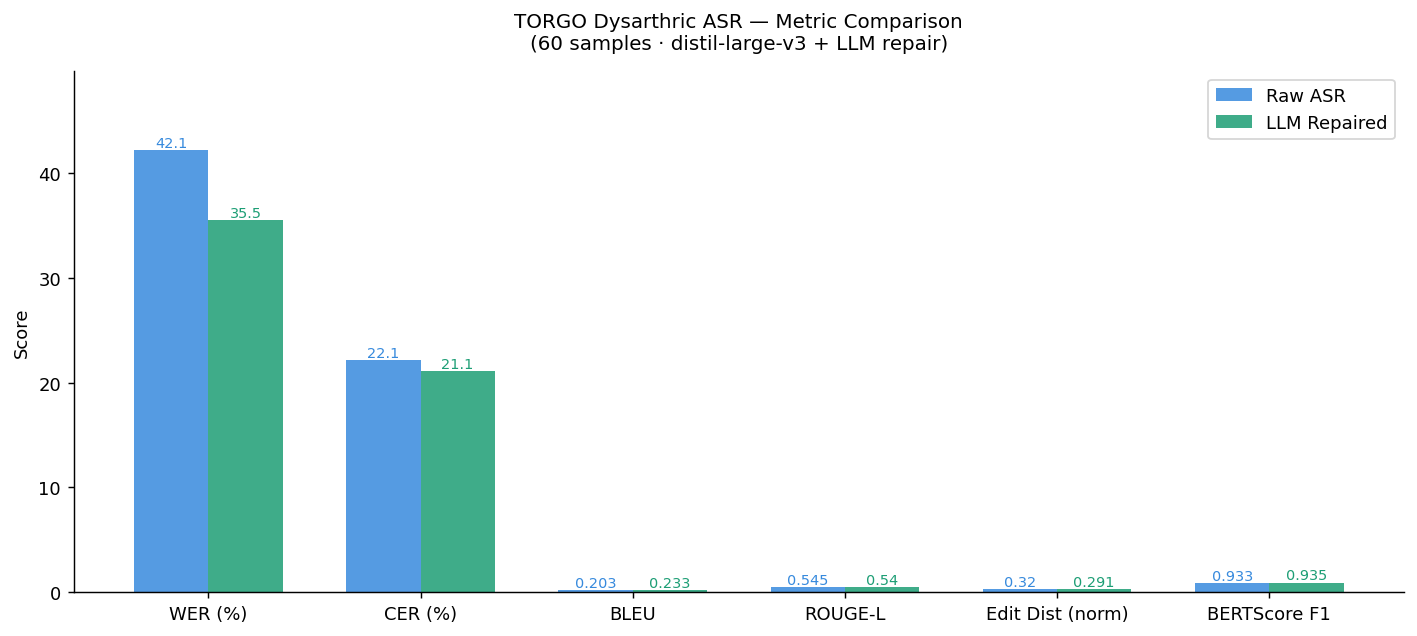

✅ Saved 01_metric_comparison.png


In [ ]:
metrics_cfg = [
    ("WER (%)",          raw["WER_%"],         rep["WER_%"],         True),
    ("CER (%)",          raw["CER_%"],          rep["CER_%"],          True),
    ("BLEU",             raw["BLEU"],           rep["BLEU"],           False),
    ("ROUGE-L",          raw["ROUGE_L"],        rep["ROUGE_L"],        False),
    ("Edit Dist (norm)", raw["edit_dist_norm"], rep["edit_dist_norm"], True),
    ("BERTScore F1",     raw["BERTScore_F1"],   rep["BERTScore_F1"],   False),
]
labels   = [m[0] for m in metrics_cfg]
raw_vals = [m[1] for m in metrics_cfg]
rep_vals = [m[2] for m in metrics_cfg]

x, w = np.arange(len(labels)), 0.35

fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x - w/2, raw_vals, w, label="Raw ASR",      color=C_RAW, alpha=0.85)
b2 = ax.bar(x + w/2, rep_vals, w, label="LLM Repaired", color=C_REP, alpha=0.85)

for bar in b1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{bar.get_height():.3g}", ha="center", va="bottom", fontsize=8, color=C_RAW)
for bar in b2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{bar.get_height():.3g}", ha="center", va="bottom", fontsize=8, color=C_REP)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel("Score", fontsize=10)
ax.set_title(
    f"TORGO Dysarthric ASR — Metric Comparison\n"
    f"({data['n_samples']} samples · {data['model_asr'].split('/')[-1]} + LLM repair)",
    fontsize=11, pad=12
)
ax.legend(fontsize=10)
ax.set_ylim(0, max(max(raw_vals), max(rep_vals)) * 1.18)

plt.tight_layout()
plt.savefig("torgo_plots/01_metric_comparison.png", bbox_inches="tight")
plt.show()
print("✅ Saved 01_metric_comparison.png")

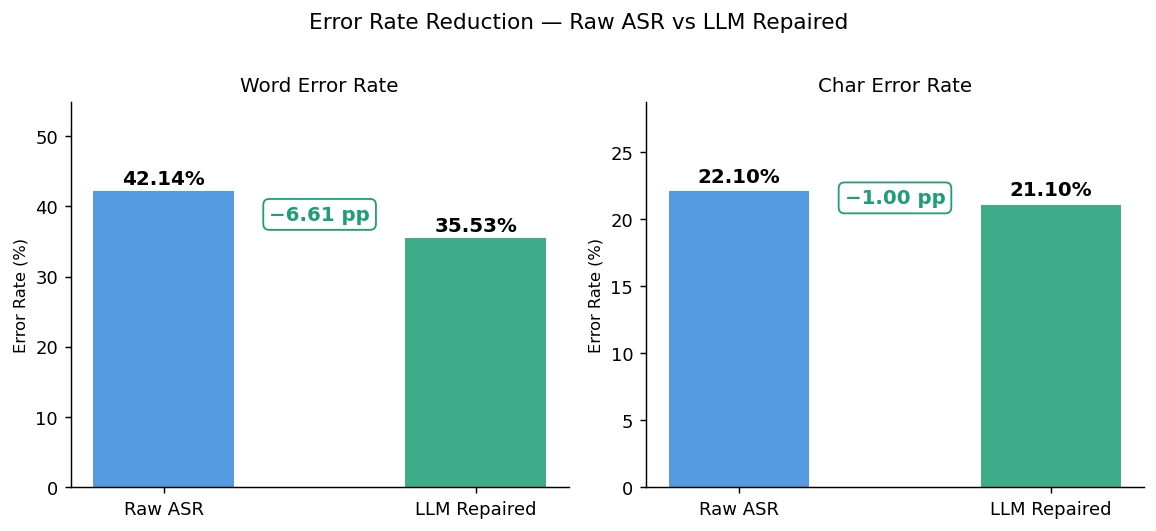

✅ Saved 02_wer_cer_improvement.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

for ax, r_val, p_val, label in zip(
    axes,
    [raw["WER_%"], raw["CER_%"]],
    [rep["WER_%"], rep["CER_%"]],
    ["Word Error Rate", "Char Error Rate"],
):
    bars = ax.bar(["Raw ASR", "LLM Repaired"], [r_val, p_val],
                  color=[C_RAW, C_REP], alpha=0.85, width=0.45)

    for bar, val in zip(bars, [r_val, p_val]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
                f"{val:.2f}%", ha="center", va="bottom", fontsize=11, fontweight="bold")

    delta = r_val - p_val
    ax.text(0.5, (r_val + p_val) / 2,
            f"−{delta:.2f} pp",
            ha="center", va="center", fontsize=11, fontweight="bold", color=C_REP,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                      edgecolor=C_REP, linewidth=1))

    ax.set_title(label, fontsize=11)
    ax.set_ylim(0, r_val * 1.3)
    ax.set_ylabel("Error Rate (%)", fontsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle("Error Rate Reduction — Raw ASR vs LLM Repaired", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig("torgo_plots/02_wer_cer_improvement.png", bbox_inches="tight")
plt.show()
print("✅ Saved 02_wer_cer_improvement.png")

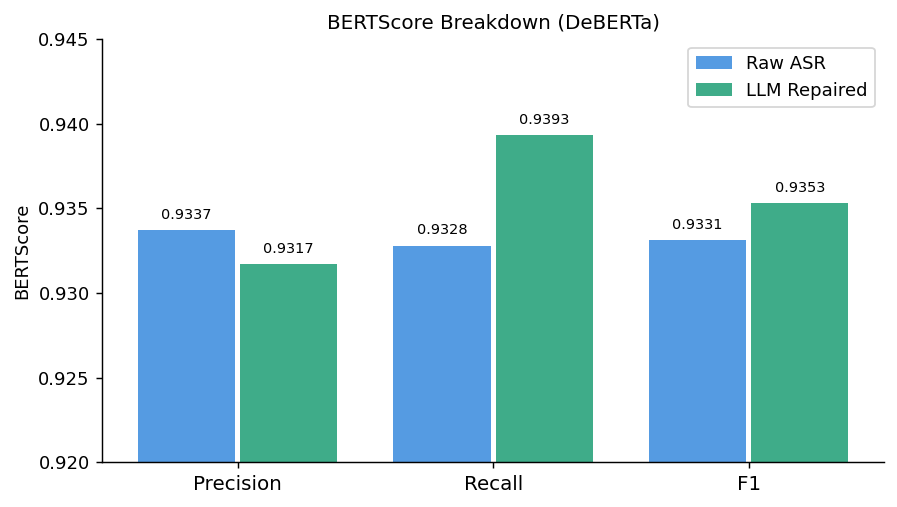

✅ Saved 03_bertscore.png


In [ ]:
bert_labels = ["Precision", "Recall", "F1"]
bert_raw    = [raw["BERTScore_P"], raw["BERTScore_R"], raw["BERTScore_F1"]]
bert_rep    = [rep["BERTScore_P"], rep["BERTScore_R"], rep["BERTScore_F1"]]

x = np.arange(len(bert_labels))
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - 0.2, bert_raw, 0.38, label="Raw ASR",      color=C_RAW, alpha=0.85)
ax.bar(x + 0.2, bert_rep, 0.38, label="LLM Repaired", color=C_REP, alpha=0.85)

for i, (rv, pv) in enumerate(zip(bert_raw, bert_rep)):
    ax.text(i - 0.2, rv + 0.0005, f"{rv:.4f}", ha="center", va="bottom", fontsize=8)
    ax.text(i + 0.2, pv + 0.0005, f"{pv:.4f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(bert_labels, fontsize=11)
ax.set_ylim(0.92, 0.945)
ax.set_ylabel("BERTScore", fontsize=10)
ax.set_title("BERTScore Breakdown (DeBERTa)", fontsize=11)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig("torgo_plots/03_bertscore.png", bbox_inches="tight")
plt.show()
print("✅ Saved 03_bertscore.png")

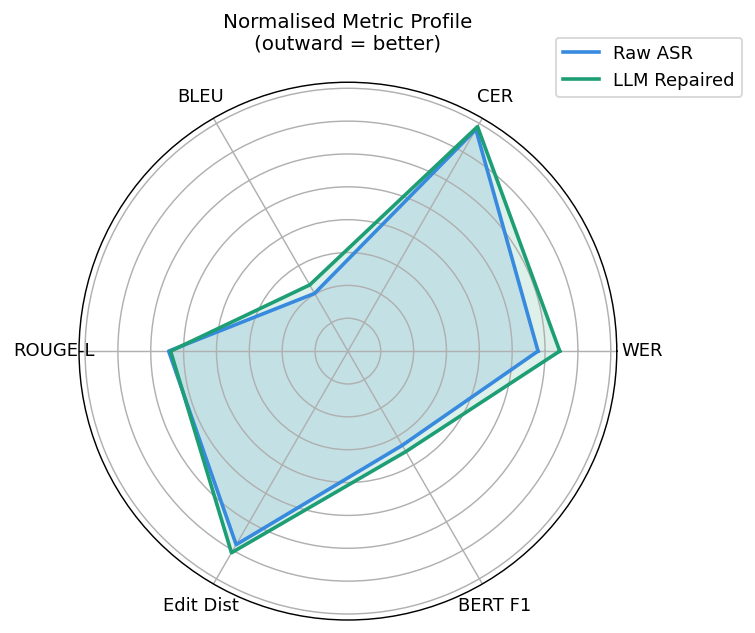

✅ Saved 04_radar.png


In [ ]:
def norm(val, min_v, max_v, invert=False):
    n = (val - min_v) / (max_v - min_v + 1e-9)
    return 1 - n if invert else n

radar_metrics = ["WER", "CER", "BLEU", "ROUGE-L", "Edit Dist", "BERT F1"]
raw_r = [
    norm(raw["WER_%"],         0, 100, invert=True),
    norm(raw["CER_%"],         0, 100, invert=True),
    norm(raw["BLEU"],          0, 1),
    norm(raw["ROUGE_L"],       0, 1),
    norm(raw["edit_dist_norm"],0, 1,   invert=True),
    norm(raw["BERTScore_F1"],  0.9, 1),
]
rep_r = [
    norm(rep["WER_%"],         0, 100, invert=True),
    norm(rep["CER_%"],         0, 100, invert=True),
    norm(rep["BLEU"],          0, 1),
    norm(rep["ROUGE_L"],       0, 1),
    norm(rep["edit_dist_norm"],0, 1,   invert=True),
    norm(rep["BERTScore_F1"],  0.9, 1),
]

angles = np.linspace(0, 2 * np.pi, len(radar_metrics), endpoint=False).tolist()
angles += angles[:1];  raw_r += raw_r[:1];  rep_r += rep_r[:1]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
ax.plot(angles, raw_r, color=C_RAW, linewidth=2, label="Raw ASR")
ax.fill(angles, raw_r, color=C_RAW, alpha=0.15)
ax.plot(angles, rep_r, color=C_REP, linewidth=2, label="LLM Repaired")
ax.fill(angles, rep_r, color=C_REP, alpha=0.15)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_metrics, fontsize=10)
ax.set_yticklabels([])
ax.set_title("Normalised Metric Profile\n(outward = better)", fontsize=11, pad=18)
ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.1), fontsize=10)

plt.tight_layout()
plt.savefig("torgo_plots/04_radar.png", bbox_inches="tight")
plt.show()
print("✅ Saved 04_radar.png")

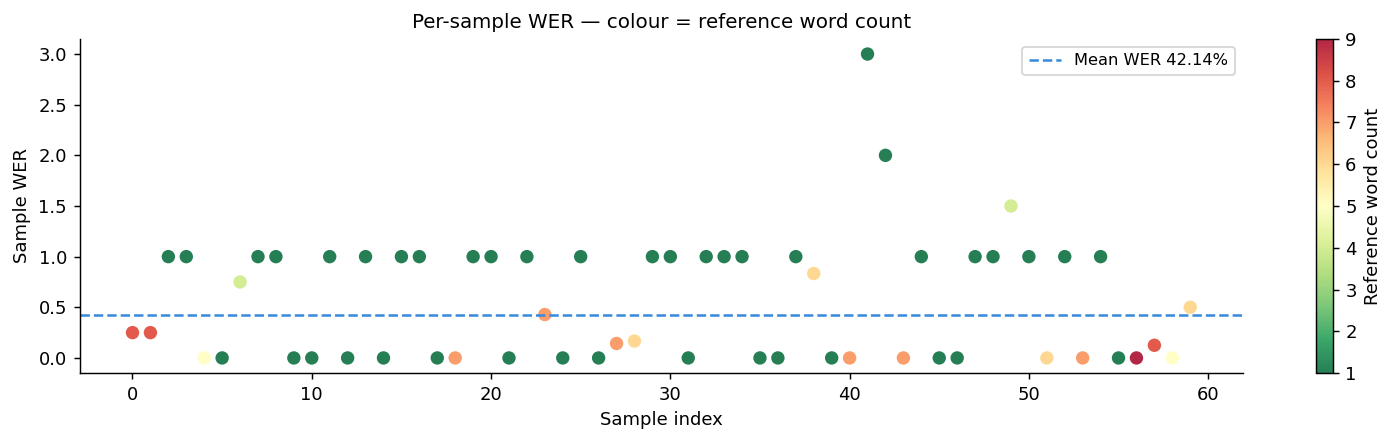

✅ Saved 05_per_sample_wer.png


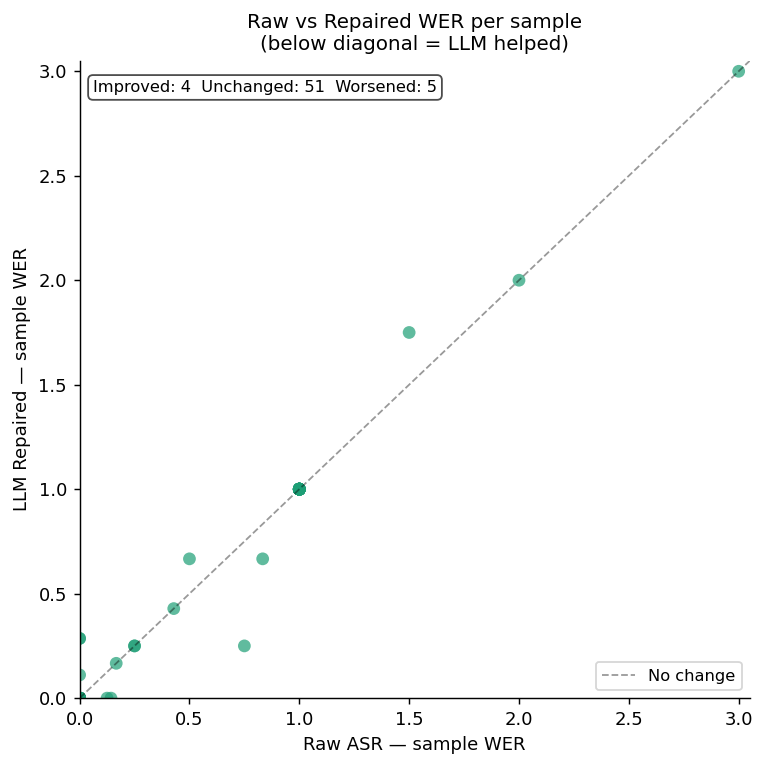

✅ Saved 06_raw_vs_repaired_scatter.png


In [ ]:
from jiwer import wer as _wer

sample_wers, rep_sample_wers = [], []
for p in preds:
    ref   = p["reference"].strip().lower()
    raw_t = p["raw_asr"].strip().lower().rstrip(".")
    rep_t = p["repaired"].strip().lower()
    try:    sw = _wer([ref], [raw_t])
    except: sw = 1.0
    try:    rw = _wer([ref], [rep_t])
    except: rw = 1.0
    sample_wers.append(sw)
    rep_sample_wers.append(rw)

ref_lens = [len(p["reference"].split()) for p in preds]

# Plot 5 — per-sample strip
fig, ax = plt.subplots(figsize=(12, 3.5))
sc = ax.scatter(range(len(preds)), sample_wers, c=ref_lens,
                cmap="RdYlGn_r", s=55, alpha=0.85, edgecolors="none")
ax.axhline(raw["WER_%"] / 100, color=C_RAW, linewidth=1.4,
           linestyle="--", label=f"Mean WER {raw['WER_%']}%")
ax.set_xlabel("Sample index", fontsize=10)
ax.set_ylabel("Sample WER", fontsize=10)
ax.set_title("Per-sample WER — colour = reference word count", fontsize=11)
ax.legend(fontsize=9)
plt.colorbar(sc, ax=ax, label="Reference word count")
plt.tight_layout()
plt.savefig("torgo_plots/05_per_sample_wer.png", bbox_inches="tight")
plt.show()
print("✅ Saved 05_per_sample_wer.png")

# Plot 6 — scatter raw vs repaired
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(sample_wers, rep_sample_wers, color=C_REP, alpha=0.7, s=50, edgecolors="none")
lim = max(max(sample_wers), max(rep_sample_wers)) + 0.05
ax.plot([0, lim], [0, lim], "k--", linewidth=1, alpha=0.4, label="No change")
ax.set_xlabel("Raw ASR — sample WER", fontsize=10)
ax.set_ylabel("LLM Repaired — sample WER", fontsize=10)
ax.set_title("Raw vs Repaired WER per sample\n(below diagonal = LLM helped)", fontsize=11)
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
ax.legend(fontsize=9)

improved  = sum(r < w for w, r in zip(sample_wers, rep_sample_wers))
worsened  = sum(r > w for w, r in zip(sample_wers, rep_sample_wers))
unchanged = len(preds) - improved - worsened
ax.text(0.02, 0.97,
        f"Improved: {improved}  Unchanged: {unchanged}  Worsened: {worsened}",
        transform=ax.transAxes, fontsize=9, va="top",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7))

plt.tight_layout()
plt.savefig("torgo_plots/06_raw_vs_repaired_scatter.png", bbox_inches="tight")
plt.show()
print("✅ Saved 06_raw_vs_repaired_scatter.png")

In [ ]:
rows = []
for p in data["predictions"][:15]:
    ref   = p["reference"].strip().lower()
    rep_t = p["repaired"].strip().lower().rstrip(".")
    match = "correct" if ref == rep_t else "wrong"
    rows.append({
        "#":         p["idx"],
        "Reference": p["reference"],
        "Raw ASR":   p["raw_asr"],
        "Repaired":  p["repaired"],
        "Match":     match,
    })

df_preds = pd.DataFrame(rows)

styled = df_preds.style.set_properties(**{
    "text-align":       "left",
    "font-size":        "13px",
    "padding":          "8px 14px",
    "color":            "#2c2c2c",
    "background-color": "#ffffff",
}).set_table_styles([
    # Header
    {"selector": "th", "props": [
        ("background-color", "#1D9E75"),
        ("color",            "#ffffff"),
        ("font-weight",      "600"),
        ("font-size",        "13px"),
        ("padding",          "10px 14px"),
        ("text-align",       "left"),
        ("border-bottom",    "2px solid #157a5a"),
    ]},
    # Alternating row stripe
    {"selector": "tr:nth-child(even) td", "props": [
        ("background-color", "#edf7f3"),
    ]},
    # Hover effect
    {"selector": "tr:hover td", "props": [
        ("background-color", "#c8ecde"),
    ]},
    # Table border
    {"selector": "table", "props": [
        ("border-collapse", "collapse"),
        ("border",          "1px solid #b2ddd0"),
        ("border-radius",   "8px"),
        ("overflow",        "hidden"),
        ("width",           "100%"),
    ]},
    # Cell borders
    {"selector": "td", "props": [
        ("border-bottom", "1px solid #d8eeea"),
    ]},
]).hide(axis="index")

display(styled)

#,Reference,Raw ASR,Repaired,Match
0,day after day some new episode is reported,"day after day, some new episodes is reported.",day after day some new episodes are reported,wrong
1,beg that guard for one gallon of gas,make that good for one gallon of gas.,make that good for one gallon of gas,wrong
2,him,mb,mb,wrong
3,select,selec.,selec,wrong
4,although always alone we survive,although always alone we survive.,although always alone we survive,correct
5,pat,pat.,pat,correct
6,although always again again,"although always, again, again, again.",although always again again again,wrong
7,sway,shui.,shui,wrong
8,sell,zheel.,zheel,wrong
9,cake,cake.,cake,correct
